# 06. 極・零点・安定性 — 極の位置が応答と安定性を決める

| 層 | セクション |
|---|---|
| Basic | 1. Big Picture 〜 5. Definition |
| Applied | 6. Computation 〜 9. Application |
| Advanced | 10. Exercises / 11. Advanced Notes |

> 極 $D(s)=0$ の位置(左半面/虚軸/右半面)が、減衰・持続・発散をそのまま決める。

In [1]:
# Shared setup: make laplace_book importable, fix seeds, inline + plotly rendering.
%matplotlib inline
import sys
from pathlib import Path

try:
    import laplace_book  # noqa: F401
except ModuleNotFoundError:
    for _base in (Path.cwd(), *Path.cwd().parents):
        if (_base / "src" / "laplace_book").is_dir():
            sys.path.insert(0, str(_base / "src"))
            break

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from IPython.display import display

from laplace_book import transforms, systems, circuits, plotting, datasets, widgets, discrete
from laplace_book.transforms import t, s, L, Linv, numeric_laplace, partial_fractions

import plotly.io as pio
pio.renderers.default = "notebook_connected"

np.random.seed(0)
np.set_printoptions(precision=4, suppress=True)
sp.init_printing()

## 1. Big Picture

伝達関数 $H(s)=\dfrac{N(s)}{D(s)}$ の **極**(分母 $D(s)=0$ の根)が、時間応答の形と安定性を決めます。
極の位置を $s$ 平面で読むだけで、減衰するか・振動するか・発散するかが分かります。

## 2. Problem / 3. Intuition

各極 $s_k=\sigma_k+i\omega_k$ は、応答に項 $e^{\sigma_k t}\,(\cos/\sin\,\omega_k t)$ を1つ持ち込みます(01 章の $e^{st}$)。
だから「極の実部 $\sigma_k$ の符号」がそのまま安定性、「虚部 $\omega_k$」が振動の速さになります。

## 4. Visualization — 極の位置と応答の形

代表的な4つの極配置と、それぞれの応答を並べます。

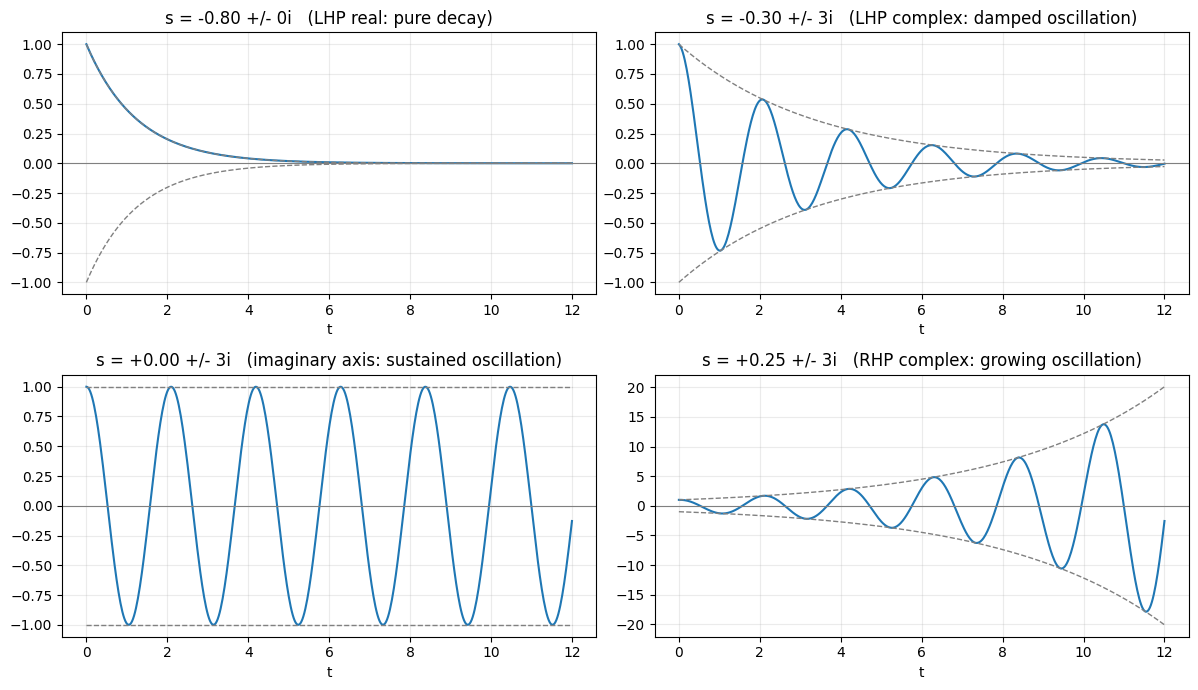

In [2]:
tt = np.linspace(0, 12, 500)
cases = [
    (-0.8, 0.0, "LHP real: pure decay"),
    (-0.3, 3.0, "LHP complex: damped oscillation"),
    (0.0, 3.0, "imaginary axis: sustained oscillation"),
    (0.25, 3.0, "RHP complex: growing oscillation"),
]
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, (sig, om, lab) in zip(axes.ravel(), cases):
    y = np.exp(sig * tt) * np.cos(om * tt)
    ax.plot(tt, y, color=plotting.ACCENT)
    ax.plot(tt, np.exp(sig * tt), "--", color="gray", lw=1)
    ax.plot(tt, -np.exp(sig * tt), "--", color="gray", lw=1)
    ax.axhline(0, color="gray", lw=0.8)
    ax.set_title(f"s = {sig:+.2f} +/- {om:.0f}i   ({lab})")
    ax.set_xlabel("t"); ax.grid(alpha=0.25)
fig.tight_layout()

## 5. Definition / 6. Computation — 極・零点と s 平面

- **零点**: $N(s)=0$ の根(応答を弱める方向)。
- **極**: $D(s)=0$ の根(応答の形を決める)。

例として $H(s)=\dfrac{s+1}{s^2+s+4}$ の極・零点を $s$ 平面に描きます。

poles: [-0.5+1.9365j -0.5-1.9365j]
zeros: [-1.]
stability: stable


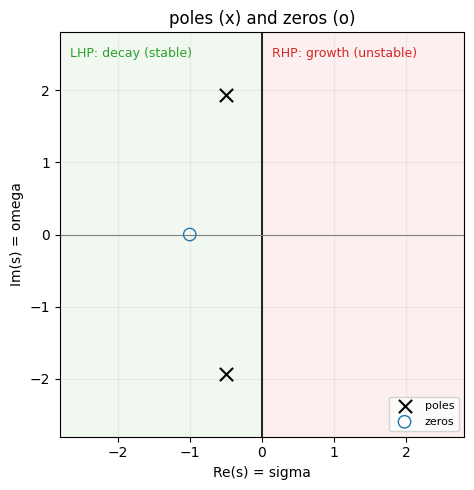

In [3]:
H = systems.tf([1.0, 1.0], [1.0, 1.0, 4.0])
print("poles:", systems.poles(H))
print("zeros:", systems.zeros(H))
print("stability:", systems.classify_stability(H))
plotting.plot_s_plane(poles=systems.poles(H), zeros=systems.zeros(H), title="poles (x) and zeros (o)")
plt.tight_layout()

## 6b. |F(s)| を s 平面上の地形として見る (Applied, interactive)

$|H(s)|$ を $s$ 平面上の高さとして描くと、**極が山のように尖ります**。下は $H=1/((s+1)^2+9)$、
極 $s=-1\pm3i$。マウスで回して、尖りの真下に極があることを確かめてください。

In [4]:
H_eval = lambda S: 1.0 / ((S + 1.0) ** 2 + 9.0)   # poles at s = -1 +/- 3i
fig = plotting.surface_abs_F(H_eval, sigma_range=(-3, 1), omega_range=(-7, 7), n=70)
fig

## 7. Invariant / Structure — 安定性の判定

- **左半面 (LHP, $\sigma<0$)**: すべての極がここなら **安定**(過渡応答は消える)。
- **虚軸上 ($\sigma=0$)**: 持続振動の **臨界**(marginal)。
- **右半面 (RHP, $\sigma>0$)**: 1つでもあれば **不安定**(発散)。

`systems.classify_stability` がこの判定を行います。

In [5]:
examples = {
    "1/(s+1)        ": systems.first_order(1.0),
    "1/(s^2+s+4)    ": systems.tf([1.0], [1.0, 1.0, 4.0]),
    "1/(s^2+4)      ": systems.tf([1.0], [1.0, 0.0, 4.0]),
    "1/(s-1)        ": systems.tf([1.0], [1.0, -1.0]),
}
for name, sysk in examples.items():
    print(f"{name}: poles={np.round(systems.poles(sysk), 3)}  ->  {systems.classify_stability(sysk)}")

1/(s+1)        : poles=[-1.]  ->  stable
1/(s^2+s+4)    : poles=[-0.5+1.936j -0.5-1.936j]  ->  stable
1/(s^2+4)      : poles=[-0.+2.j  0.-2.j]  ->  marginal
1/(s-1)        : poles=[1.]  ->  unstable


## 7b. Routh-Hurwitz — 係数だけで安定判定 (Advanced)

極を数値で求めなくても、分母の **係数だけ** から右半面極の数が分かるのが Routh-Hurwitz 判定。
Routh 表の第1列の符号変化の回数 = 右半面極の数(0 なら安定)。`systems.routh_hurwitz` が判定・極数・表を返す。

In [6]:
for den in ([1, 6, 11, 6], [1, 1, 1, 6], [1, 6, 11, 106]):
    stable, n_rhp, _ = systems.routh_hurwitz(den)
    truth = int(np.sum(np.roots(den).real > 1e-9))   # cross-check against the actual roots
    print(f"den={den}:  Routh n_rhp={n_rhp} (roots say {truth})  ->  {'stable' if stable else 'unstable'}")

den=[1, 6, 11, 6]:  Routh n_rhp=0 (roots say 0)  ->  stable
den=[1, 1, 1, 6]:  Routh n_rhp=2 (roots say 2)  ->  unstable
den=[1, 6, 11, 106]:  Routh n_rhp=2 (roots say 2)  ->  unstable


## 8. Failure Mode / 過渡応答 と 定常応答

ステップ応答は **過渡(極が決める、やがて消える)** と **定常(入力の極 $s=0$ が決める、残る)** の和。
減衰比 $\zeta$ を動かして、極の位置(左の図)と応答(右の図)の連動を見ます。

In [7]:
# Interactive: wn and zeta move the pole pair and reshape the step response.
widgets.explore_second_order()

interactive(children=(FloatSlider(value=1.0, description='wn', max=3.0, min=0.3), FloatSlider(value=0.3, descr…

<function laplace_book.widgets.explore_second_order.<locals>._draw(wn=1.0, zeta=0.3)>

## 8b. 安定境界をまたぐアニメーション (Applied)

共役な極対の実部 $\sigma$ を負から正へ動かすと、極が虚軸を横切り、応答が **減衰 → 持続 → 発散** と
変わる。安定性の境界(虚軸)を目で追う。

In [8]:
from IPython.display import HTML

anim = plotting.animate_pole_crossing(omega=3.0)
html = anim.to_jshtml(fps=8)
plt.close("all")
HTML(html)

## 9. Application

- **制御設計**: 望む応答(速さ・行き過ぎ)になるよう、極を左半面の狙った位置へ動かす(07 章)。
- **共振回避**: 虚軸近くの極は鋭い共振 → ダンピングで左へ。

## 10. Exercises / 11. Advanced

- **Basic**: $1/((s+2)^2+9)$ の極を求め、減衰の速さと振動数を読め。
- **Applied**: $1/(s^2+bs+1)$ の $b$ を $0\to3$ と変え、極の軌跡(根軌跡の一種)を $s$ 平面に描け。
- **Advanced**: `systems.routh_hurwitz`(§7b)で $1/(s^2+bs+1)$ を判定し、$b<0$ で不安定になることを確かめよ。
- **Advanced**: 零点は応答の **形** に効くが安定性には効かない理由を説明せよ。